# H.E.S.S. I (CT3)

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import Camera, Telescope, hexshow, show_telescope

## Load telescope and camera

In [2]:
telescope = Telescope.from_yaml(
    '../../configs/HESS/CT3.yaml',
    n_samples=128,
    key=jax.random.key(42),
)
camera = Camera.from_yaml('../../configs/HESS/HESS1U.yaml')

E0508 14:50:18.603392 1765822 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0508 14:50:18.603650 1765824 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0508 14:50:18.603637 1765823 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


In [3]:
telescope = telescope.apply_roughness(0, 12)

## 3D scene

In [5]:
scene = show_telescope(telescope)
scene.show(viewer='jupyter')

## Star field image

<Axes: >

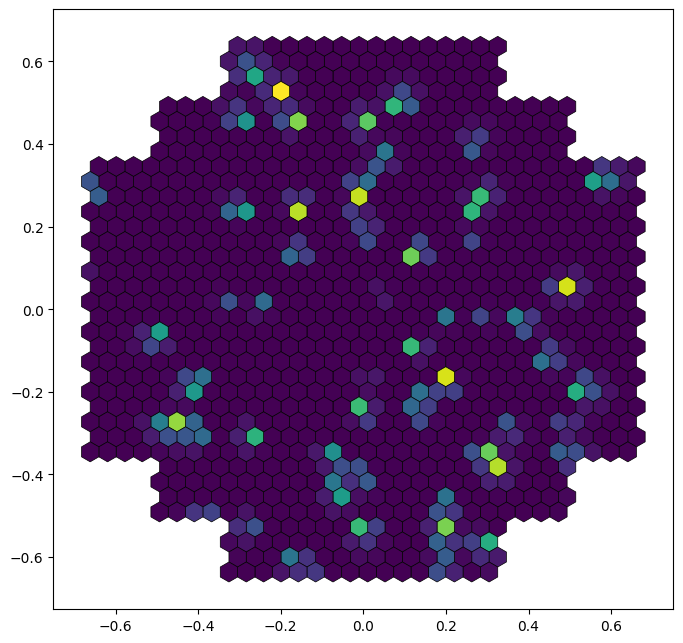

In [6]:
n_stars = 100
key1, key2 = jax.random.split(jax.random.key(42))

fov_deg = 6
fov_rad = fov_deg * jnp.pi / 180

x = jax.random.uniform(key1, (n_stars,), minval=-fov_rad/2, maxval=fov_rad/2)
y = jax.random.uniform(key2, (n_stars,), minval=-fov_rad/2, maxval=fov_rad/2)
z = -jnp.ones(n_stars)

stars = jnp.stack([x, y, z], axis=1)
stars = stars / jnp.linalg.norm(stars, axis=1, keepdims=True)

f_stars = jax.random.uniform(jax.random.key(4242), shape=(len(stars),))

rays = telescope.render(stars, f_stars, source_type='parallel')
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
ax1 = hexshow(image, camera.sensor_groups[0], ax=ax)

## Bokeh from a finite-distance point source

<Axes: >

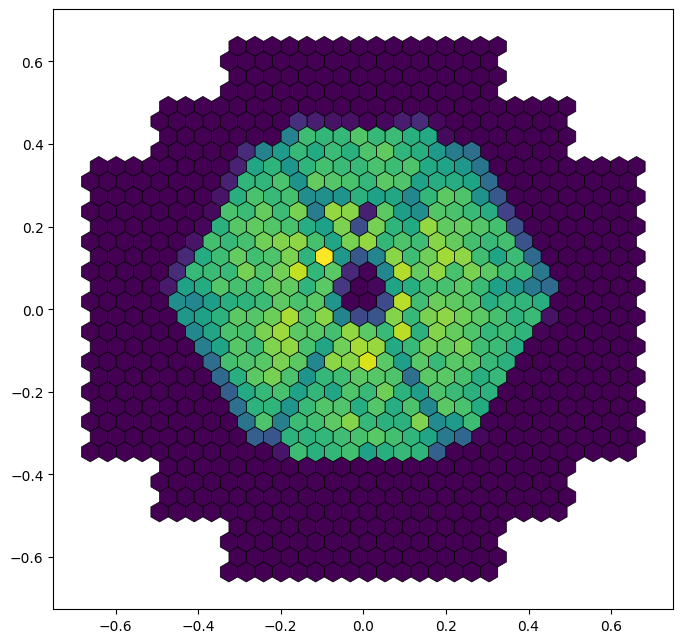

In [7]:
N_points = 1
key1, key2 = jax.random.split(jax.random.key(45))

x = jax.random.uniform(key1, N_points, minval=-1, maxval=1)
y = jax.random.uniform(key2, N_points, minval=-1, maxval=1)
z = jnp.ones(N_points) * 250

points = jnp.array([x, y, z]).T
f_points = jnp.ones(len(points))

rays = telescope.render(points, f_points, source_type='point')
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
ax1 = hexshow(image, camera.sensor_groups[0], ax=ax)

## Spot diagram from explicit ray geometry

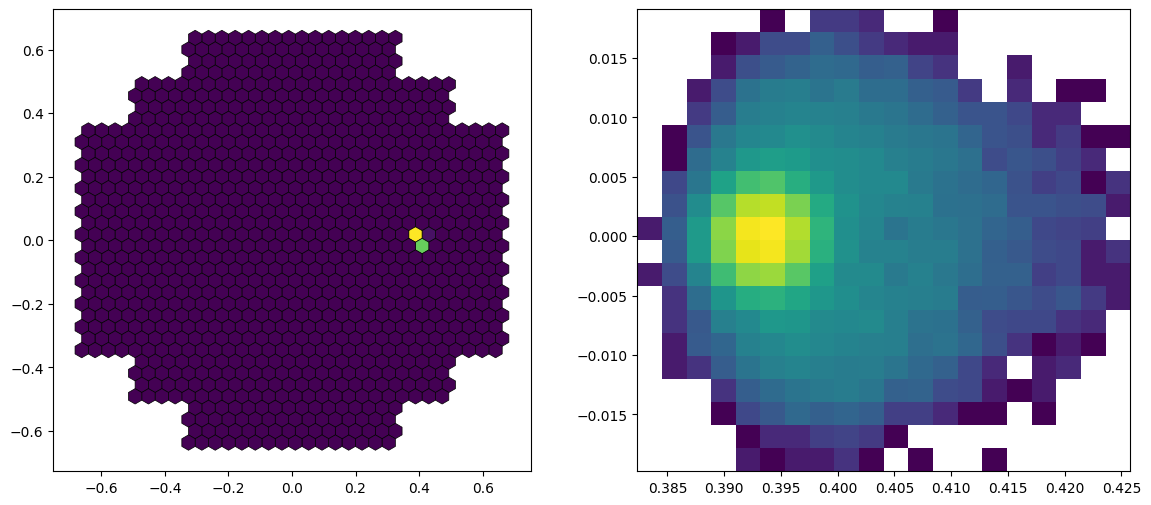

In [8]:
from iactrace.camera.camera import intersect_sensor

n_rays = 100000
key1, key2 = jax.random.split(jax.random.key(123))

r = 6.0 * jnp.sqrt(jax.random.uniform(key1, (n_rays,)))
theta = jax.random.uniform(key2, (n_rays,)) * 2 * jnp.pi
ray_origins = jnp.stack([
    r * jnp.cos(theta),
    r * jnp.sin(theta),
    jnp.ones(n_rays) * 100.0,
], axis=1)

tilt_angle = 1.5 * jnp.pi / 180
ray_directions = jnp.broadcast_to(
    jnp.array([jnp.sin(tilt_angle), 0.0, -jnp.cos(tilt_angle)]),
    (n_rays, 3),
)
ray_values = jnp.ones(n_rays)

rays = telescope.trace(ray_origins, ray_directions, ray_values)
image = camera.image(rays)
sensor_rays, _, hit_mask = intersect_sensor(camera, rays, sensor_idx=0)

fig, ax = plt.subplots(ncols=2, figsize=(14, 6))
hexshow(image, camera.sensor_groups[0], ax=ax[0])
h2 = ax[1].hist2d(
    sensor_rays.origins[hit_mask, 0],
    sensor_rays.origins[hit_mask, 1],
    bins=20, norm='log',
)